Name: Sakshi Jadhav  
Roll No.: EN23107043   
Department: AIDS-A  
Subject: AI-PD  

<h3>ASSIGNMENT NO-02</h3>

Dataset: https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("spotify_data.csv")
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [3]:
print(df.columns)

Index(['track_id', 'track_name', 'track_number', 'track_popularity',
       'explicit', 'artist_name', 'artist_popularity', 'artist_followers',
       'artist_genres', 'album_id', 'album_name', 'album_release_date',
       'album_total_tracks', 'album_type', 'track_duration_min'],
      dtype='object')


In [4]:
df['popular'] = df['track_popularity'].apply(lambda x: 1 if x >= 60 else 0)

In [5]:
le = LabelEncoder()

df["explicit"] = le.fit_transform(df["explicit"])
df["album_type"] = le.fit_transform(df["album_type"])

In [6]:
features = [
"artist_popularity",
"artist_followers",
"track_duration_min",
"album_total_tracks",
"explicit",
"album_type"
]

X = df[features]
y = df["popular"]

In [7]:
df[features].describe()

,artist_popularity,artist_followers,track_duration_min,album_total_tracks,explicit,album_type
count,8582.000000,8.582000e+03,8582.000000,8582.000000,8582.000000,8582.000000
mean,69.730016,2.403472e+07,3.492805,13.789443,0.250291,0.576206
std,19.645979,3.803180e+07,1.057970,11.887131,0.433206,0.872588
min,0.000000,0.000000e+00,0.070000,1.000000,0.000000,0.000000
25%,60.000000,4.623200e+05,2.880000,6.000000,0.000000,0.000000
50%,74.000000,6.105547e+06,3.445000,13.000000,0.000000,0.000000
75%,84.000000,2.725255e+07,3.990000,17.000000,1.000000,2.000000
max,100.000000,1.455421e+08,13.510000,181.000000,1.000000,2.000000


In [8]:
df[features].isnull().sum()

artist_popularity     0
artist_followers      0
track_duration_min    0
album_total_tracks    0
explicit              0
album_type            0
dtype: int64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Logistic Regression\n")

print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1 Score:", f1_score(y_test, pred_lr))

Logistic Regression

Accuracy: 0.7169481654047758
Precision: 0.6716899892357373
Recall: 0.7751552795031056
F1 Score: 0.7197231833910035


In [12]:
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
print("SVM\n")

print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Precision:", precision_score(y_test, pred_svm))
print("Recall:", recall_score(y_test, pred_svm))
print("F1 Score:", f1_score(y_test, pred_svm))

SVM

Accuracy: 0.7198602213162493
Precision: 0.6514018691588785
Recall: 0.8658385093167702
F1 Score: 0.7434666666666667


In [13]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Random Forest\n")

print("Accuracy:", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall:", recall_score(y_test, pred_rf))
print("F1 Score:", f1_score(y_test, pred_rf))

Random Forest

Accuracy: 0.755387303436226
Precision: 0.7367773677736777
Recall: 0.7440993788819876
F1 Score: 0.7404202719406675


In [14]:
model = Sequential([
Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
Dense(16, activation='relu'),
Dense(1, activation='sigmoid')
])

model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

model.fit(
X_train,
y_train,
epochs=20,
batch_size=32,
validation_split=0.2
)

Epoch 1/20


C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6723 - loss: 0.5977 - val_accuracy: 0.6890 - val_loss: 0.5688
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7087 - loss: 0.5362 - val_accuracy: 0.7007 - val_loss: 0.5536
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7139 - loss: 0.5286 - val_accuracy: 0.7058 - val_loss: 0.5478
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7152 - loss: 0.5259 - val_accuracy: 0.7116 - val_loss: 0.5436
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7174 - loss: 0.5235 - val_accuracy: 0.7087 - val_loss: 0.5422
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7178 - loss: 0.5222 - val_accuracy: 0.7079 - val_loss: 0.5413
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7183 - loss: 0.5205 - val_accuracy: 0.7109 - val_loss: 0.5406
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7216 - loss: 0.5190 - val_accuracy: 0.7028 - val_

In [15]:
loss, acc = model.evaluate(X_test, y_test)
print("TensorFlow Accuracy:", acc)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - accuracy: 0.7111 - loss: 0.5303
TensorFlow Accuracy: 0.711124062538147


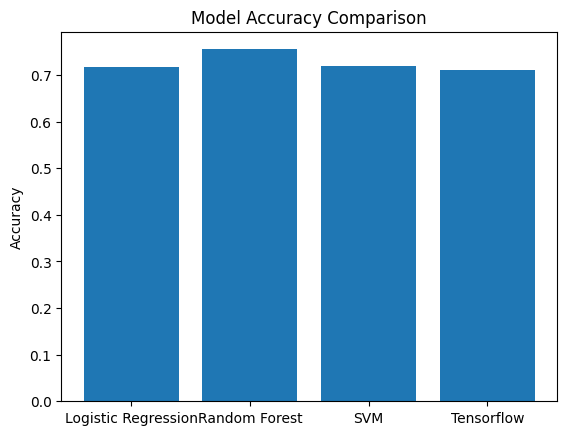

In [16]:
results = {
    "Logistic Regression": accuracy_score(y_test, pred_lr),
    "Random Forest": accuracy_score(y_test, pred_rf),
    "SVM": accuracy_score(y_test, pred_svm),
    "Tensorflow": acc
}

plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

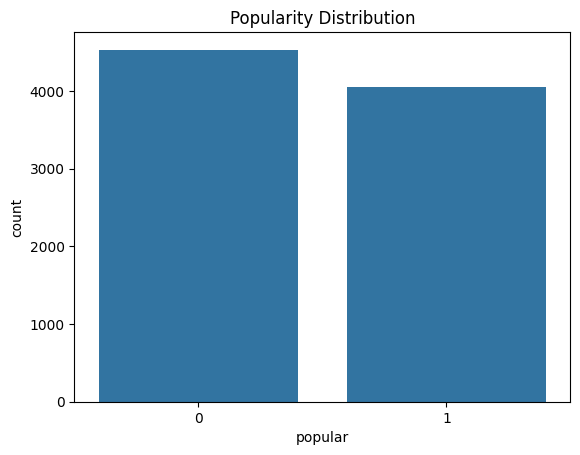

In [17]:
sns.countplot(x=df["popular"])
plt.title("Popularity Distribution")
plt.show()

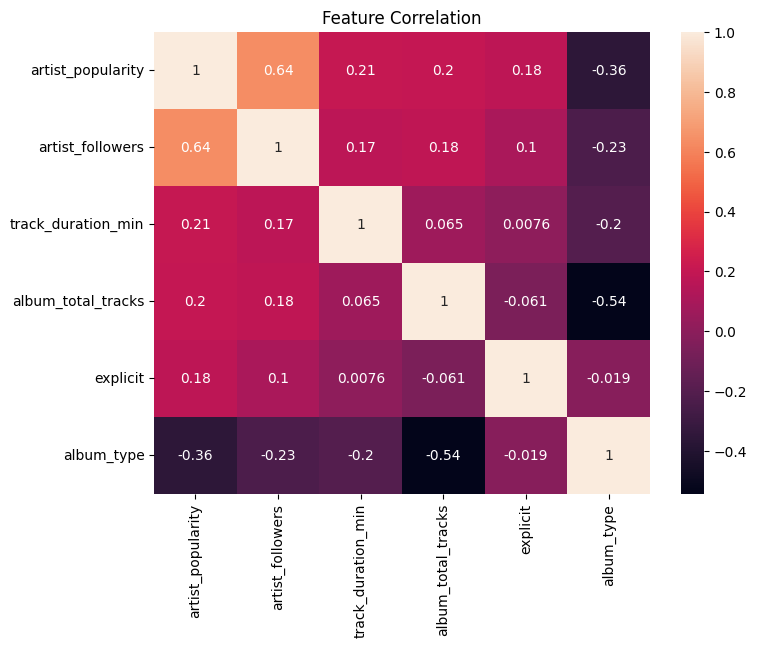

In [18]:
corr = df[features].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation")
plt.show()

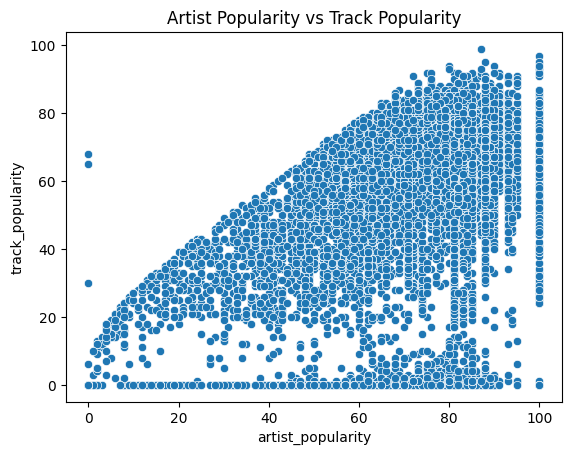

In [19]:
sns.scatterplot(x=df["artist_popularity"],y=df["track_popularity"])
plt.title("Artist Popularity vs Track Popularity")
plt.show()

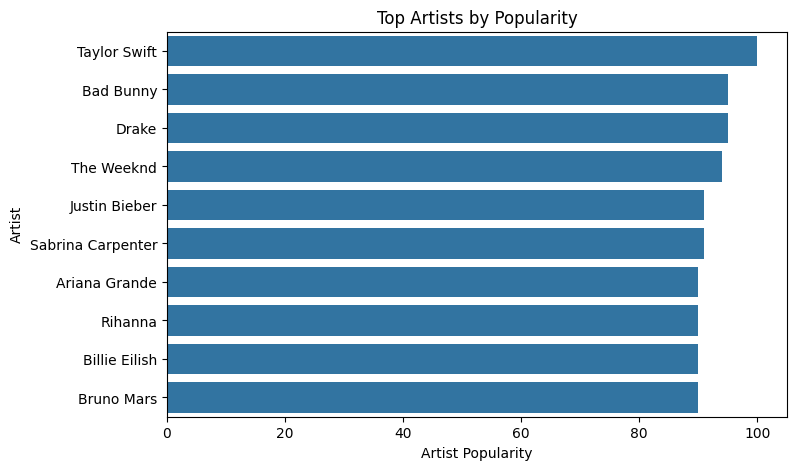

In [20]:
top_artists = df.sort_values(
    by="artist_popularity",
    ascending=False
).drop_duplicates("artist_name").head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x="artist_popularity",
    y="artist_name",
    data=top_artists
)

plt.title("Top Artists by Popularity")
plt.xlabel("Artist Popularity")
plt.ylabel("Artist")

plt.show()

In [24]:
artist_popularity = float(input("Artist popularity: "))
artist_followers = float(input("Artist followers: "))
duration = float(input("Track duration (min): "))
album_tracks = int(input("Album total tracks: "))
explicit = int(input("Explicit (0=No,1=Yes): "))
album_type = int(input("Album type (encoded): "))

sample = [[artist_popularity,artist_followers,duration,
album_tracks,explicit,album_type]]

sample = scaler.transform(sample)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Prediction: Popular Track")
else:
    print("Prediction: Not Popular")

Artist popularity:  95
Artist followers:  750000000
Track duration (min):  3.4
Album total tracks:  8
Explicit (0=No,1=Yes):  0
Album type (encoded):  1


Prediction: Popular Track


C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
